In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shinchanreturns/transformer-train-small/OrSa
/kaggle/input/datasets/shinchanreturns/transformer-train-small/AcMi
/kaggle/input/datasets/shinchanreturns/transformer-train-small/AcPh
/kaggle/input/datasets/shinchanreturns/transformer-train-small/SaEn
/kaggle/input/datasets/shinchanreturns/transformer-train-small/ObLa
/kaggle/input/datasets/shinchanreturns/transformer-train-small/SaCe
/kaggle/input/datasets/shinchanreturns/transformer-test-small/YeMi


Loading training data...
Train: 224,823 blocks | Val: 24,981 blocks
Total training k-mer tokens: 79,937,414


/tmp/ipykernel_58/2036395102.py:105: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=N_LAYERS)
/tmp/ipykernel_58/2036395102.py:352: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_58/2036395102.py:372: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Model parameters: 4,869,888


/tmp/ipykernel_58/2036395102.py:391: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch   1/40 | Train Loss 1.7100 Acc 0.2977 BPB 2.4670 | Val Loss 1.3369 Acc 0.3481 BPB 1.9288 | LR 2.00e-04
Epoch   2/40 | Train Loss 1.3496 Acc 0.3379 BPB 1.9470 | Val Loss 1.3337 Acc 0.3509 BPB 1.9241 | LR 1.99e-04
Epoch   3/40 | Train Loss 1.3461 Acc 0.3405 BPB 1.9421 | Val Loss 1.3326 Acc 0.3517 BPB 1.9226 | LR 1.97e-04
Epoch   4/40 | Train Loss 1.3439 Acc 0.3424 BPB 1.9388 | Val Loss 1.3321 Acc 0.3526 BPB 1.9218 | LR 1.95e-04
Epoch   5/40 | Train Loss 1.3421 Acc 0.3438 BPB 1.9363 | Val Loss 1.3315 Acc 0.3529 BPB 1.9210 | LR 1.93e-04
Epoch   7/40 | Train Loss 1.3389 Acc 0.3464 BPB 1.9316 | Val Loss 1.3296 Acc 0.3545 BPB 1.9181 | LR 1.86e-04
Epoch   8/40 | Train Loss 1.3374 Acc 0.3477 BPB 1.9294 | Val Loss 1.3292 Acc 0.3552 BPB 1.9177 | LR 1.82e-04
Epoch   9/40 | Train Loss 1.3364 Acc 0.3485 BPB 1.9280 | Val Loss 1.3287 Acc 0.3554 BPB 1.9169 | LR 1.77e-04
Epoch  10/40 | Train Loss 1.3355 Acc 0.3494 BPB 1.9267 | Val Loss 1.3281 Acc 0.3558 BPB 1.9161 | LR 1.72e-04
Epoch  11/40 | Trai

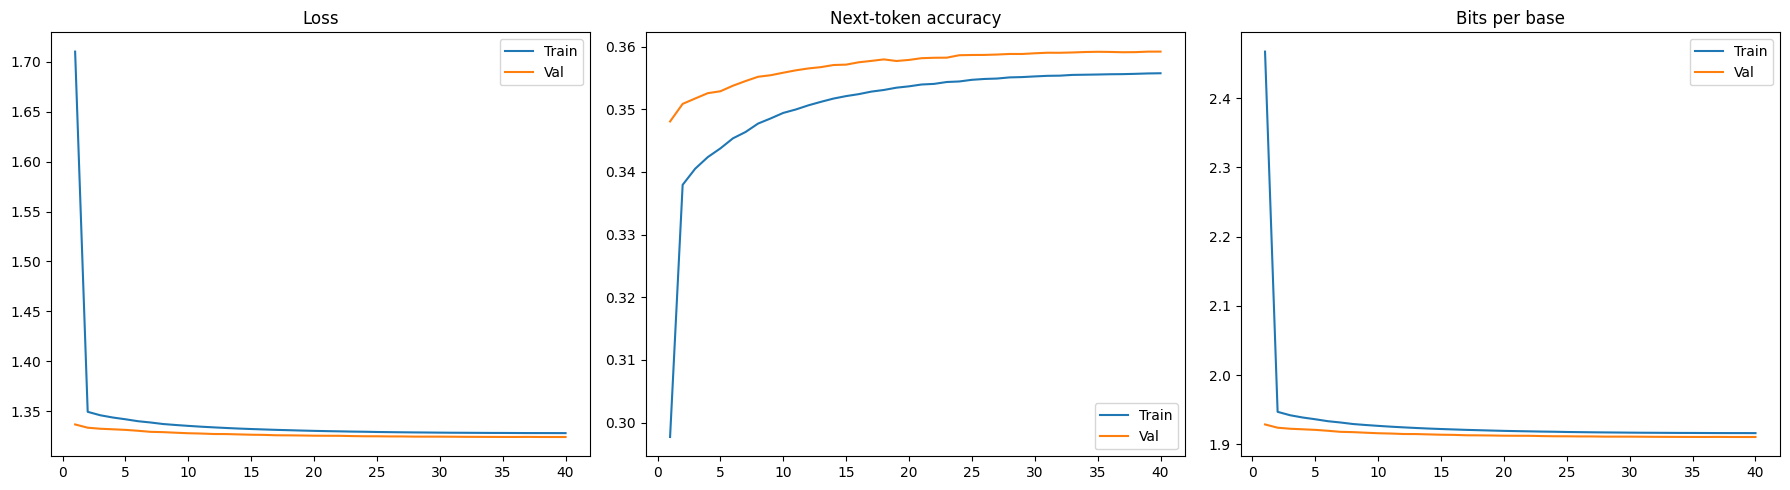


FILE : YeMi
  Original size      : 73,689 bytes
  DNA length         : 73,689 bases
  K-mer tokens       : 73,686


/tmp/ipykernel_58/2036395102.py:473: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Compressed size    : 17,074 bytes  (23.2%)
  Compression ratio  : 4.316x
  Compression time   : 286.32s
  Compressed BPB     : 1.8536
  Model BPB          : 1.8530
  Decompression time : 287.50s
  Total time         : 574.82s
  Lossless verify    : ✓ PERFECT
  Reconstruction acc : 100.0000%


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os, json, struct, random, math, time
import numpy as np
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler

# ================= CONFIG =================
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
K          = 4
KMER_VOCAB = 4**K
BLOCK_SIZE = 320
EMBED_DIM  = 256
N_HEADS    = 8
N_LAYERS   = 6
FF_DIM     = 1024
DROPOUT    = 0.1
EPOCHS     = 40
BATCH_SIZE = 32
LR         = 2e-4

TRAIN_DIR = "/kaggle/input/datasets/shinchanreturns/transformer-train-small"
TEST_DIR  = "/kaggle/input/datasets/shinchanreturns/transformer-test-small"
OUT_DIR   = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

# ================= DNA CLEANING =================
VALID_BASES = set('ACGT')

def clean_dna(seq):
    seq = seq.upper()
    cleaned = []
    for c in seq:
        if c in VALID_BASES:
            cleaned.append(c)
    return "".join(cleaned)

def read_fasta(path):
    seq = []
    with open(path) as f:
        for l in f:
            l = l.strip().upper()
            if l and not l.startswith(">"):
                seq.append(l)
    return "".join(seq)

# ================= K-MER TOKENIZATION =================
BASE2IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
IDX2BASE = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}

def kmer_to_id(kmer):
    idx = 0
    for c in kmer:
        idx = idx * 4 + BASE2IDX[c]
    return idx

def id_to_kmer(idx, k=K):
    chars = []
    for _ in range(k):
        chars.append(IDX2BASE[idx % 4])
        idx //= 4
    return "".join(reversed(chars))

def dna_to_tokens(dna, k=K):
    tokens = []
    for i in range(len(dna) - k + 1):
        tokens.append(kmer_to_id(dna[i:i+k]))
    return tokens

def tokens_to_dna(tokens, k=K):
    if not tokens:
        return ""
    dna = id_to_kmer(tokens[0], k)
    for t in tokens[1:]:
        dna += IDX2BASE[t % 4]
    return dna

# ================= POSITIONAL ENCODING =================
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ================= CAUSAL TRANSFORMER =================
class CausalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(KMER_VOCAB, EMBED_DIM)
        self.pe  = SinusoidalPE(EMBED_DIM, max_len=BLOCK_SIZE + 1)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=EMBED_DIM, nhead=N_HEADS, dim_feedforward=FF_DIM,
            dropout=DROPOUT, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=N_LAYERS)
        self.out_proj = nn.Linear(EMBED_DIM, KMER_VOCAB)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _causal_mask(self, sz):
        return torch.triu(torch.ones(sz, sz, device=DEVICE), diagonal=1).bool()

    def forward(self, x):
        emb  = self.emb(x)
        emb  = self.pe(emb)
        mask = self._causal_mask(x.size(1))
        out  = self.transformer(emb, mask=mask, is_causal=True)
        return self.out_proj(out)

# ================= ARITHMETIC CODER =================
PRECISION  = 32
FULL       = 1 << PRECISION
HALF       = FULL >> 1
QUARTER    = FULL >> 2
CDF_SCALE  = (1 << 31) - KMER_VOCAB

def build_cdf(probs, n_symbols=KMER_VOCAB):
    counts = np.maximum(1, np.round(probs.astype(np.float64) * CDF_SCALE)).astype(np.int64)
    total  = counts.sum()
    diff   = HALF - total
    if diff > 0:
        counts[np.argmax(counts)] += diff
    elif diff < 0:
        diff = -diff
        idx  = np.argsort(counts)[::-1]
        for i in idx:
            take       = min(diff, counts[i] - 1)
            counts[i] -= take
            diff      -= take
            if diff == 0:
                break
    cdf     = np.zeros(n_symbols + 1, dtype=np.int64)
    cdf[1:] = np.cumsum(counts)
    return cdf

# ================= PROB ENGINE =================
class ProbEngine:
    """
    Runs transformer live on growing context.
    Fully standalone — only needs model weights.
    Encoder and decoder maintain identical state.
    """
    def __init__(self, model):
        self.model   = model
        self.context = []

    def reset(self):
        self.context = []

    def get_probs(self):
        self.model.float()
        self.model.eval()
        if len(self.context) == 0:
            return np.ones(KMER_VOCAB, dtype=np.float32) / KMER_VOCAB
        ctx    = self.context[-BLOCK_SIZE:]
        t      = torch.tensor([ctx], dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            logits = self.model(t)
        probs  = F.softmax(logits[0, -1], dim=-1)
        return probs.cpu().float().numpy()

    def advance(self, token):
        self.context.append(token)

# ================= LOSSLESS ENCODE =================
def lossless_encode(tokens, engine):
    engine.reset()
    low     = 0
    high    = FULL
    bits    = []
    pending = []

    def emit(bit):
        bits.append(bit)
        for _ in pending:
            bits.append(1 - bit)
        pending.clear()

    for sym in tokens:
        probs = engine.get_probs()
        cdf   = build_cdf(probs)
        total = cdf[-1]

        span  = high - low
        high  = low + (span * int(cdf[sym + 1])) // total
        low   = low + (span * int(cdf[sym]))     // total

        engine.advance(sym)

        while True:
            if high <= HALF:
                emit(0); low <<= 1; high <<= 1
            elif low >= HALF:
                emit(1)
                low  = (low  - HALF) << 1
                high = (high - HALF) << 1
            elif low >= QUARTER and high <= 3 * QUARTER:
                pending.append(None)
                low  = (low  - QUARTER) << 1
                high = (high - QUARTER) << 1
            else:
                break

    pending.append(None)
    if low < QUARTER:
        emit(0)
    else:
        emit(1)

    out = bytearray()
    for i in range(0, len(bits), 8):
        byte = 0
        for j, b in enumerate(bits[i:i+8]):
            byte |= (b << (7 - j))
        out.append(byte)
    return bytes(out)

# ================= LOSSLESS DECODE =================
def lossless_decode(data, n_tokens, engine):
    engine.reset()
    bits = []
    for byte in data:
        for j in range(7, -1, -1):
            bits.append((byte >> j) & 1)

    pos = 0
    def read_bit():
        nonlocal pos
        b = bits[pos] if pos < len(bits) else 0
        pos += 1
        return b

    low   = 0
    high  = FULL
    value = 0
    for _ in range(PRECISION):
        value = (value << 1) | read_bit()

    tokens = []
    for _ in range(n_tokens):
        probs  = engine.get_probs()
        cdf    = build_cdf(probs)
        total  = cdf[-1]
        span   = high - low
        scaled = ((value - low + 1) * total - 1) // span

        lo, hi = 0, KMER_VOCAB - 1
        while lo < hi:
            mid = (lo + hi) // 2
            if cdf[mid + 1] <= scaled:
                lo = mid + 1
            else:
                hi = mid
        sym = lo
        tokens.append(sym)

        engine.advance(sym)

        high = low + (span * int(cdf[sym + 1])) // total
        low  = low + (span * int(cdf[sym]))     // total

        while True:
            if high <= HALF:
                low <<= 1; high <<= 1
                value = (value << 1) | read_bit()
            elif low >= HALF:
                low   = (low   - HALF) << 1
                high  = (high  - HALF) << 1
                value = (value - HALF) << 1
                value |= read_bit()
            elif low >= QUARTER and high <= 3 * QUARTER:
                low   = (low   - QUARTER) << 1
                high  = (high  - QUARTER) << 1
                value = (value - QUARTER) << 1
                value |= read_bit()
            else:
                break

    return tokens

# ================= LOSS & METRICS =================
def loss_fn(logits, targets):
    return F.cross_entropy(
        logits[:, :-1].reshape(-1, KMER_VOCAB),
        targets[:, 1:].reshape(-1)
    )

def accuracy_fn(logits, targets):
    preds   = torch.argmax(logits[:, :-1], dim=-1)
    correct = (preds == targets[:, 1:])
    return correct.float().mean().item()

def bits_per_base(logits, targets, k=K):
    ce = F.cross_entropy(
        logits[:, :-1].reshape(-1, KMER_VOCAB),
        targets[:, 1:].reshape(-1)
    )
    return (ce.item() / math.log(2)) 

# ================= DATA LOADING =================
def load_tokens(directory):
    all_tokens = []
    for fname in os.listdir(directory):
        path = os.path.join(directory, fname)
        if not os.path.isfile(path): continue
        dna    = clean_dna(read_fasta(path))
        tokens = dna_to_tokens(dna)
        all_tokens.extend(tokens)
    return all_tokens

print("Loading training data...")
train_tokens = load_tokens(TRAIN_DIR)
if not train_tokens:
    raise RuntimeError("No training data found")

def make_blocks(tokens, size):
    blocks = []
    for i in range(0, len(tokens) - size, size):
        blocks.append(tokens[i:i+size+1])
    return blocks

blocks = make_blocks(train_tokens, BLOCK_SIZE)
random.seed(42)
random.shuffle(blocks)

data       = torch.tensor(blocks, dtype=torch.long)
n          = len(data)
train_size = int(0.9 * n)
train_data = data[:train_size]
val_data   = data[train_size:]

print(f"Train: {len(train_data):,} blocks | Val: {len(val_data):,} blocks")
print(f"Total training k-mer tokens: {len(train_tokens):,}")

# ================= TRAINING =================
model     = CausalTransformer().to(DEVICE)
opt       = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler    = GradScaler()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR/20)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []
train_bpb_hist,  val_bpb_hist  = [], []
best_val_loss = float('inf')
best_path     = f"{OUT_DIR}/best_model.pt"

for e in range(EPOCHS):
    model.train()
    perm   = torch.randperm(train_data.size(0))
    t_loss = 0.0; t_acc = 0.0; t_bpb = 0.0; steps = 0

    for i in range(0, train_data.size(0), BATCH_SIZE):
        batch = train_data[perm[i:i+BATCH_SIZE]].to(DEVICE)
        opt.zero_grad()
        with autocast():
            logits = model(batch)
            loss   = loss_fn(logits, batch)
        acc = accuracy_fn(logits, batch)
        bpb = bits_per_base(logits, batch)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()
        t_loss += loss.item(); t_acc += acc; t_bpb += bpb; steps += 1

    t_loss /= steps; t_acc /= steps; t_bpb /= steps
    scheduler.step()

    model.eval()
    v_loss = 0.0; v_acc = 0.0; v_bpb = 0.0; vsteps = 0
    with torch.no_grad():
        for i in range(0, val_data.size(0), BATCH_SIZE):
            batch = val_data[i:i+BATCH_SIZE].to(DEVICE)
            with autocast():
                logits = model(batch)
            v_loss += loss_fn(logits, batch).item()
            v_acc  += accuracy_fn(logits, batch)
            v_bpb  += bits_per_base(logits, batch)
            vsteps += 1
    v_loss /= vsteps; v_acc /= vsteps; v_bpb /= vsteps

    train_loss_hist.append(t_loss); val_loss_hist.append(v_loss)
    train_acc_hist.append(t_acc);   val_acc_hist.append(v_acc)
    train_bpb_hist.append(t_bpb);   val_bpb_hist.append(v_bpb)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), best_path)

    print(f"Epoch {e+1:3d}/{EPOCHS} | "
          f"Train Loss {t_loss:.4f} Acc {t_acc:.4f} BPB {t_bpb:.4f} | "
          f"Val Loss {v_loss:.4f} Acc {v_acc:.4f} BPB {v_bpb:.4f} | "
          f"LR {scheduler.get_last_lr()[0]:.2e}")

print(f"\nBest val loss: {best_val_loss:.4f}")
model.load_state_dict(torch.load(best_path))

r = range(1, EPOCHS+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(r, train_loss_hist, label="Train"); axes[0].plot(r, val_loss_hist, label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(r, train_acc_hist, label="Train"); axes[1].plot(r, val_acc_hist, label="Val")
axes[1].set_title("Next-token accuracy"); axes[1].legend()
axes[2].plot(r, train_bpb_hist, label="Train"); axes[2].plot(r, val_bpb_hist, label="Val")
axes[2].set_title("Bits per base"); axes[2].legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_plots.png")
plt.show()

# ================= COMPRESSION ENGINE =================
model.eval()

# ================= TESTING =================
for fname in os.listdir(TEST_DIR):
    path = os.path.join(TEST_DIR, fname)
    if not os.path.isfile(path): continue

    t_start_total = time.time()

    raw_dna = read_fasta(path)
    dna     = clean_dna(raw_dna)
    tokens  = dna_to_tokens(dna)
    n_tok   = len(tokens)
    orig_sz = os.path.getsize(path)
    prefix  = f"{OUT_DIR}/{os.path.splitext(fname)[0]}"

    print(f"\n{'='*60}")
    print(f"FILE : {fname}")
    print(f"  Original size      : {orig_sz:,} bytes")
    print(f"  DNA length         : {len(dna):,} bases")
    print(f"  K-mer tokens       : {n_tok:,}")

    # ---- Compression ----
    engine       = ProbEngine(model)
    t_comp_start = time.time()
    compressed   = lossless_encode(tokens, engine)
    comp_time    = time.time() - t_comp_start

    meta        = {"n_tokens": n_tok, "dna_len": len(dna), "k": K, "version": 1}
    meta_bytes  = json.dumps(meta).encode()
    meta_len    = struct.pack('>I', len(meta_bytes))
    bundle      = meta_len + meta_bytes + compressed

    comp_path   = f"{prefix}.dnacomp"
    with open(comp_path, 'wb') as f:
        f.write(bundle)

    comp_sz  = os.path.getsize(comp_path)
    ratio    = orig_sz / comp_sz
    comp_bpb = (comp_sz * 8) / len(dna)

    model_bpb_vals = []
    with torch.no_grad():
        for i in range(0, n_tok - BLOCK_SIZE, BLOCK_SIZE):
            chunk  = torch.tensor([tokens[i:i+BLOCK_SIZE+1]], dtype=torch.long, device=DEVICE)
            with autocast():
                logits = model(chunk)
            model_bpb_vals.append(bits_per_base(logits, chunk))
    model_bpb = float(np.mean(model_bpb_vals)) if model_bpb_vals else 0.0

    print(f"  Compressed size    : {comp_sz:,} bytes  ({comp_sz/orig_sz*100:.1f}%)")
    print(f"  Compression ratio  : {ratio:.3f}x")
    print(f"  Compression time   : {comp_time:.2f}s")
    print(f"  Compressed BPB     : {comp_bpb:.4f}")
    print(f"  Model BPB          : {model_bpb:.4f}")

    # ---- Decompression ----
    t_decomp_start = time.time()

    with open(comp_path, 'rb') as f:
        raw = f.read()

    meta_len_back  = struct.unpack('>I', raw[:4])[0]
    meta_back      = json.loads(raw[4:4+meta_len_back])
    comp_data_back = raw[4+meta_len_back:]
    n_tok_back     = meta_back["n_tokens"]

    engine         = ProbEngine(model)
    decoded_tokens = lossless_decode(comp_data_back, n_tok_back, engine)

    decomp_time = time.time() - t_decomp_start
    total_time  = time.time() - t_start_total

    recon_dna  = tokens_to_dna(decoded_tokens, k=K)[:len(dna)]
    ok         = recon_dna == dna
    mismatches = sum(a != b for a, b in zip(dna, recon_dna)) if not ok else 0
    recon_acc  = 1.0 - mismatches / len(dna)

    print(f"  Decompression time : {decomp_time:.2f}s")
    print(f"  Total time         : {total_time:.2f}s")
    print(f"  Lossless verify    : {'✓ PERFECT' if ok else f'✗ {mismatches:,} mismatches'}")
    print(f"  Reconstruction acc : {recon_acc*100:.4f}%")

    with open(f"{prefix}_reconstructed.txt", 'w') as f:
        f.write(recon_dna)